In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize
from scipy.signal import find_peaks

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [90]:
savepath = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures'

In [3]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [10]:
mean_paths = [glob.glob(os.path.join(asset.derived_dir,'**','glutamate_mean_df.npz'),recursive=True)[0] for asset in assets]
for i,asset in enumerate(assets):
    print(i,asset.session_id)

0 803496_2025-07-25_13-02-10
1 803496_2025-07-28_08-04-39
2 803496_2025-07-29_13-34-35
3 803496_2025-07-30_10-05-23
4 803496_2025-07-31_09-43-28
5 803496_2025-08-01_13-22-49
6 804730_2025-07-25_14-08-35
7 804730_2025-07-28_13-57-34
8 804730_2025-07-29_14-55-04
9 804730_2025-07-30_11-11-11
10 804730_2025-07-31_11-45-27
11 804730_2025-08-01_14-22-38
12 804733_2025-07-25_15-17-00
13 804733_2025-07-28_19-00-06
14 804733_2025-07-29_16-02-24
15 804733_2025-07-30_12-59-44
16 804733_2025-07-31_13-29-01
17 804733_2025-08-01_15-20-32
18 810196_2025-07-25_16-24-20
19 810196_2025-07-28_19-59-05
20 810196_2025-07-29_17-02-41
21 810196_2025-07-31_08-28-08
22 810196_2025-07-31_14-19-46
23 810196_2025-08-01_16-37-27
24 809047_2025-10-29_10-16-32
25 809047_2025-10-30_10-06-43
26 809047_2025-10-31_12-00-50
27 809047_2025-11-01_17-51-59
28 809047_2025-11-05_10-13-00
29 809047_2025-11-06_11-05-31
30 803121_2025-10-29_11-19-29
31 803121_2025-10-30_11-13-32
32 803121_2025-10-31_13-05-26
33 803121_2025-11-01

In [11]:
act_sums = []
act_evns = []
for asset in assets:
    try:
        derived_dir = asset.derived_dir / 'glutamate' /'glutamate_analysis'
        act_sum = pd.read_parquet(os.path.join(derived_dir, 'activation_summary_table.parquet'))
        act_sums.append(act_sum)
        
        act_e = pd.read_parquet(os.path.join(derived_dir, 'activation_event_table.parquet'))
        act_evns.append(act_e)
    except Exception as e:
        print(f"An exception occurred for {asset.session_id}: {e}")
        

act_summary = pd.concat(act_sums)
act_events = pd.concat(act_evns)

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from pathlib import Path
from matplotlib.patches import Rectangle


def _rolling_mean_1d(x, win=5):
    return (
        pd.Series(np.asarray(x, dtype=float))
        .rolling(win, min_periods=1, center=False)
        .mean()
        .to_numpy()
    )


def _safe_stem(p):
    p = str(p).replace("\\", "/")
    return Path(p).stem


def plot_single_synapse_time_resolved_tuning(
    npz_path,
    dmd="DMD1",
    synapse_index=32,
    stim_image_dir=None,
    include_omission=True,
    rolling_win=5,
    sample_slice=slice(40, 150),   # matches your earlier plotting window
    image_window_sec=(0.0, 0.5),   # displayed x-range
    image_colors=None,
    residual_color="0.82",
    grand_mean_color="0.25",
    grand_mean_lw=3,
    trace_lw=3,
    shade_alpha=0.95,
    thumb_alpha=1.0,
    thumb_border_lw=3.0,
    figsize=(16, 5.5),
    title=None,
):
    """
    Plot a time-resolved tuning-curve panel for one synapse.

    Parameters
    ----------
    npz_path : str or Path
        Path to glutamate_mean_df.npz
    dmd : str
        "DMD1" or "DMD2"
    synapse_index : int
        Row index into block['image_identity'][...]['mean']
    stim_image_dir : str or Path or None
        Directory containing the stimulus TIFFs. If None, top-row thumbnails
        are left blank but titles/borders are still drawn.
    include_omission : bool
        Whether to append an omission panel.
    rolling_win : int
        Rolling mean smoothing window in samples.
    sample_slice : slice
        Slice into the time axis to display.
    image_window_sec : tuple
        (xmin, xmax) used for display.
    """

    if image_colors is None:
        image_colors = [
            "#c5cae9", "#ffcdd2", "#c8e6c9", "#ffe0b2",
            "#e1bee7", "#d7ccc8", "#9fd3f2", "#d9d9d9"
        ]

    npz = np.load(npz_path, allow_pickle=True)["data"].item()
    block = npz[dmd]

    image_keys = list(block["image_identity"].keys())
    n_images = len(image_keys)

    # Load per-image mean traces: shape -> (n_images, n_synapses, n_time)
    per_image = np.stack(
        [np.asarray(block["image_identity"][k]["mean"])[:, sample_slice] for k in image_keys],
        axis=0
    )

    n_synapses, n_time = per_image.shape[1], per_image.shape[2]
    if synapse_index >= n_synapses:
        raise IndexError(f"synapse_index={synapse_index} out of bounds for {dmd} with {n_synapses} synapses")

    grand_mean = np.nanmean(per_image, axis=0)  # (n_synapses, n_time)

    # Omission trace
    omission_trace = None
    if include_omission:
        omission_trace = np.asarray(block["omission"]["mean"])[synapse_index, sample_slice]

    # Time axis
    t = np.linspace(image_window_sec[0], image_window_sec[1], n_time)

    # Thumbnails
    image_stems = [_safe_stem(k) for k in image_keys]
    thumbs = []
    stim_image_dir = Path(stim_image_dir) if stim_image_dir is not None else None
    for stem in image_stems:
        if stim_image_dir is None:
            thumbs.append(None)
        else:
            tif_path = stim_image_dir / f"{stem}.tiff"
            thumbs.append(mpimg.imread(tif_path) if tif_path.exists() else None)

    ncols = n_images + int(include_omission)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        nrows=2,
        ncols=ncols,
        height_ratios=[0.75, 1.75],
        hspace=0.2,
        wspace=0.18,
    )

    # ----- collect y-lims across all panels for consistent scaling -----
    syn_img_traces = per_image[:, synapse_index, :]
    syn_grand = grand_mean[synapse_index, :]

    smoothed_for_ylim = [_rolling_mean_1d(syn_grand, rolling_win)]
    smoothed_for_ylim += [_rolling_mean_1d(x, rolling_win) for x in syn_img_traces]
    if omission_trace is not None:
        smoothed_for_ylim.append(_rolling_mean_1d(omission_trace, rolling_win))

    yvals = np.concatenate([x.ravel() for x in smoothed_for_ylim])
    ymin = np.nanmin(yvals)
    ymax = np.nanmax(yvals)
    ypad = 0.12 * (ymax - ymin) if ymax > ymin else 0.1 * max(abs(ymax), 1.0)
    ymin -= ypad
    ymax += ypad

    axes_bottom = []

    for col in range(ncols):
        # ---------- top thumbnail ----------
        axt = fig.add_subplot(gs[0, col])
        axt.set_xticks([])
        axt.set_yticks([])
        axt.set_facecolor("white")
        for spine in axt.spines.values():
            spine.set_visible(False)

        if col < n_images:
            label = image_stems[col]
            color = image_colors[col]
            thumb = thumbs[col]
        else:
            label = "Image\nOmission"
            color = image_colors[-1]
            thumb = None

        axt.set_title(label, fontsize=12, pad=6)

        pad = 0.035
        rect = Rectangle(
            (pad, pad),
            1 - 2 * pad,
            1 - 2 * pad,
            transform=axt.transAxes,
            fill=False,
            linewidth=thumb_border_lw,
            edgecolor=color,
            zorder=5,
        )
        axt.add_patch(rect)

        if thumb is not None:
            axt.imshow(
                thumb,
                cmap="Greys_r",
                aspect="auto",
                alpha=thumb_alpha,
                extent=(pad, 1 - pad, pad, 1 - pad),
                transform=axt.transAxes,
                zorder=2,
            )

        # ---------- bottom traces ----------
        ax = fig.add_subplot(gs[1, col])
        ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
        ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
        axes_bottom.append(ax)

        sns.despine(ax=ax)
        ax.spines["bottom"].set_linewidth(1.8)
        ax.tick_params(axis="both", labelsize=12, width=1.5, length=6)
        
        for spine in ['left','bottom']:
            ax.spines[spine].set_linewidth(3)

        if col == 0:
            ax.spines["left"].set_linewidth(1.8)
            ax.set_ylabel("Mean ΔF", fontsize=18)

        else:
            ax.spines["left"].set_visible(False)
            ax.tick_params(axis="y", left=False, labelleft=False)

        # shaded image presentation epoch
        ax.axvspan(0.0, 0.25, color=color, alpha=0.22, zorder=0)
#         ax.axvline(0.0, color="k", lw=1.5, dashes=[4, 3], alpha=0.8, zorder=1)

        mean_trace = _rolling_mean_1d(syn_grand, rolling_win)

        if col < n_images:
            img_trace = _rolling_mean_1d(syn_img_traces[col], rolling_win)
            color_trace = image_colors[col]
        else:
            img_trace = _rolling_mean_1d(omission_trace, rolling_win)
            color_trace = image_colors[-1]

        # residual shading between image trace and grand mean
        ax.fill_between(
            t,
            mean_trace,
            img_trace,
            color=residual_color,
            alpha=shade_alpha,
            zorder=2,
            linewidth=0,
        )

        ax.plot(
            t,
            img_trace,
            color=color_trace,
            lw=trace_lw,
            zorder=3,
        )
        ax.plot(
            t,
            mean_trace,
            color=grand_mean_color,
            lw=grand_mean_lw,
            zorder=4,
        )

        ax.set_xlim(*image_window_sec)
        ax.set_ylim(ymin, ymax)

        if col == 0:
            ax.set_ylabel("Mean ΔF", fontsize=18)
            ax.set_xlabel("Time from image onset (s)", fontsize=18)
        else:
            ax.set_yticklabels([])

        
        ax.set_xticks([0.0, 0.5])

    # legend
    axes_bottom[-1].plot([], [], color=grand_mean_color, lw=grand_mean_lw, label="Mean")
    axes_bottom[-1].fill_between([], [], [], color=residual_color, alpha=shade_alpha, label="Residual")
    axes_bottom[-1].legend(frameon=False, fontsize=13, loc="upper right")
    

#     fig.suptitle(title, y=0.99, fontsize=14)

    fig.tight_layout()
    return fig, axes_bottom

\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\810196\2025-07-31_810196\analysis\derived\glutamate\glutamate_mean_df.npz


<IPython.core.display.Javascript object>


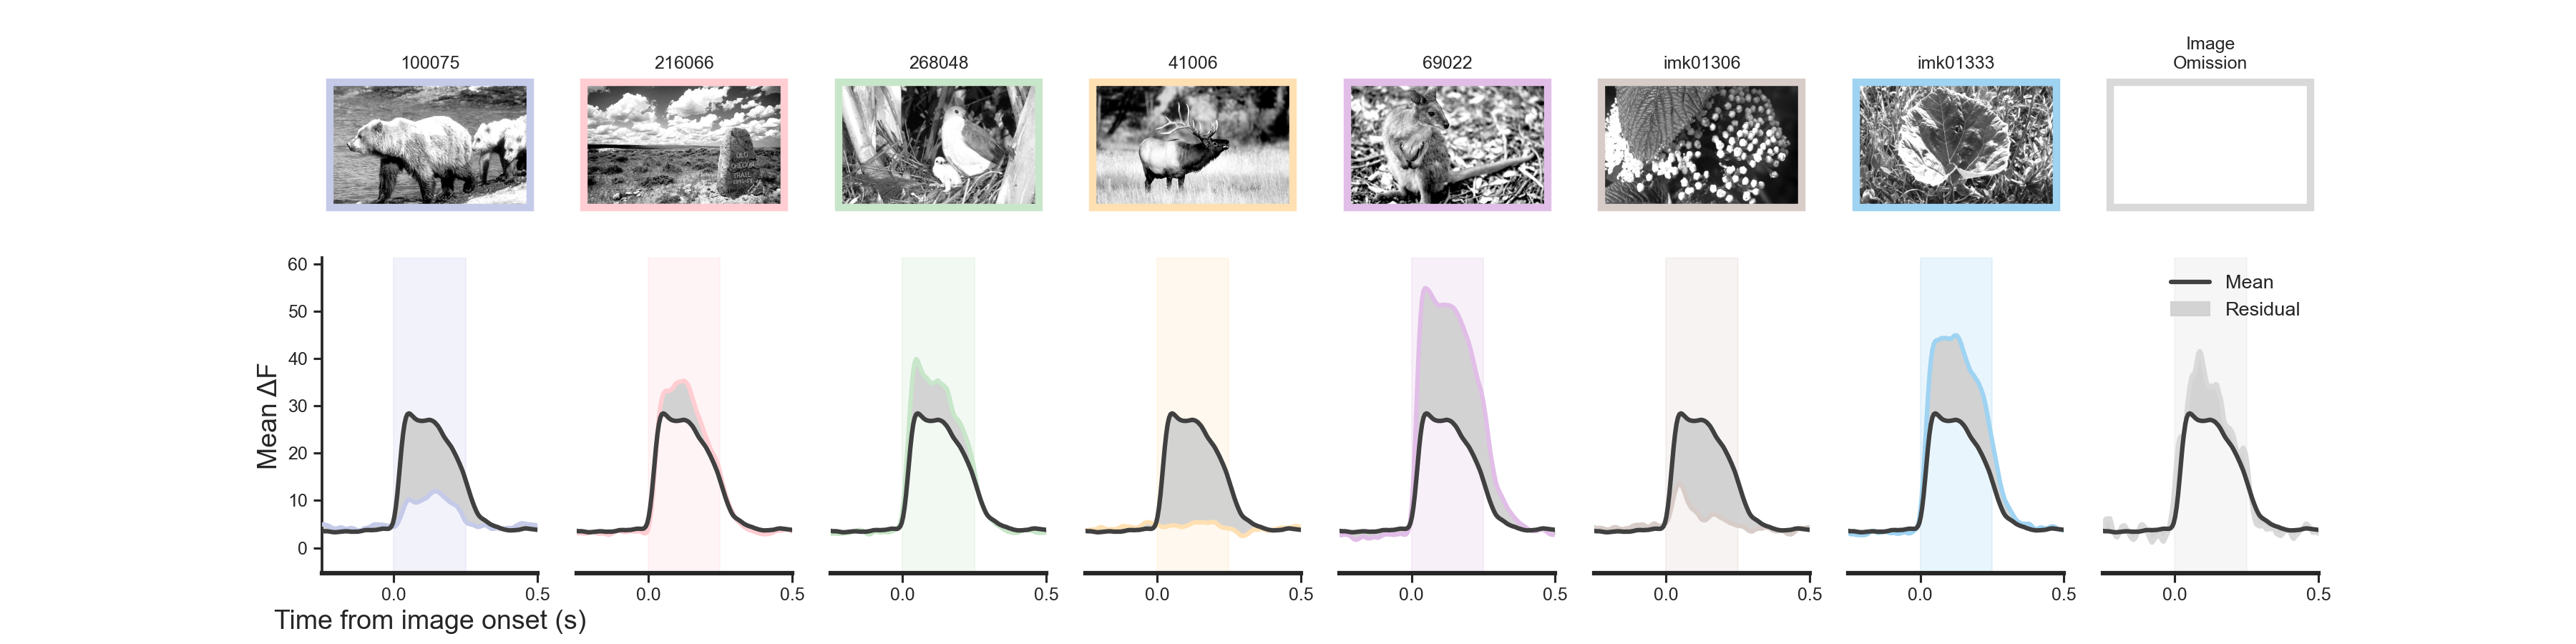

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_15296\3290947697.py:265: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [101]:
npz_path = mean_paths[22]
print(npz_path)

fig, ax = plot_single_synapse_time_resolved_tuning(
    npz_path=npz_path,
    dmd="DMD1",
    synapse_index=19,   # good example in this file
    stim_image_dir=r"C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\Aind.Behavior.ChangeDetection\src\stimuli\images_B",
    rolling_win=5,
    sample_slice=slice(0, 150),
    image_window_sec=(-0.25, 0.5),
    thumb_border_lw = 5,
    figsize=(6*4, 2*3),
)
filen = 'Residual_selective'
save_figure(fig,os.path.join(savepath,filen),formats=['.pdf','.png'],dpi=300)

In [61]:
ax

[<Axes: xlabel='Time from image onset (s)', ylabel='Mean ΔF'>,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >]